# Opdracht - 


## Inlezen van de variabelen - creëren van de omgeving

In [79]:
import os
import json
import sys
import pandas as pd
from datetime import date, datetime
import calendar
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    "figure.facecolor":    "white",
    "axes.facecolor":      "#F8F9FA",
    "axes.grid":           True,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.titlesize":      14,
    "axes.titleweight":    "bold",
    "axes.labelsize":      13,
    "axes.labelcolor":     "#333333",
    "xtick.labelsize":     12,
    "ytick.labelsize":     12,
    "xtick.color":         "#555555",
    "ytick.color":         "#555555",
    "grid.color":          "white",
    "grid.linewidth":      1.2,
    "lines.linewidth":     1.5,
    "legend.fontsize":     10,
    "font.family":         "Arial"
})

os.chdir(r"C:\Users\kurtm\Documents\Oefening01.01")



# Lees de configuratie in
config = load_project_config(r"./config.json")

kleuren = config["Plot"]["kleuren"]


## Main programma - lees de broninformatie in

In [5]:



#Overloop alle files in de Source directory
SourceDir = os.path.join(config["Directories"]["Root"],config["Directories"]["Data"],config["Directories"]["Input"])

df_births = pd.DataFrame()

for ReadFile in os.listdir(SourceDir):
    # lees de file in
    if  not ReadFile.endswith('.csv'):
        continue
    EchteGeboortedag = os.path.splitext(ReadFile)[0] 
    #bepaal of geldige datum in filenaam - check dan in de config wat je moet doen
    if not is_geldige_datum(EchteGeboortedag):
        functie_naam = config["Decisions"]["Wrong Date"]
        if not functie_naam in globals() or callable(globals()[functie_naam]):
            continue
        EchteGeboortedag = globals()[functie_naam](EchteGeboortedag)


    df_File = pd.read_csv(os.path.join(SourceDir,ReadFile))
    df_File['verwachte datum'] = pd.to_datetime(df_File['verwachte datum'])
    df_File["date"] = pd.to_datetime(EchteGeboortedag)
    df_File["SourceFile"] = ReadFile
    df_births = pd.concat([df_births, df_File], ignore_index=True)

df_births = df_births.sort_values('date')
df_births["dag van het jaar"] = df_births["date"].dt.dayofyear
df_births["dag van de week"] = df_births["date"].dt.dayofweek
df_births.to_excel(os.path.join(config["Directories"]["Root"],config["Directories"]["Data"],config["Directories"]["Temp"],config["Files"]["RestFile"]), index=False)


# Main programma - voer oefeningen uit

## Stap 1: data inlezen (1 pnt)

Bouw één DataFrame `df_births` met alle geboortes uit de map `data/geboortes`.

**Output**
- `df_births` bevat alle rijen uit alle CSV-bestanden.
- `df_births` bevat een kolom `date` als echte datetime (`YYYY-MM-DD`), afgeleid uit de bestandsnaam.
- `df_births` bevat een kolom `dag_van_jaar` met waarden van 1 tot 365.
- De observatie-grain is identiek aan de bron: **1 rij = 1 geboorte**.

**Te tonen checks**
- Aantal rijen in `df_births`
- Minimum- en maximumdatum
- Minimum en maximum van `day_of_year`
- Geen onbestaande datums (bv. dag 0, dag 32, 29/2 in niet-schrikkeljaren, geboortejaar 2027,...)

In [6]:
df_births.dtypes

gemeente                       str
naam                           str
geslacht                       str
verwachte datum     datetime64[us]
date                datetime64[us]
SourceFile                     str
dag van het jaar             int32
dag van de week              int32
dtype: object

In [7]:
len(df_births)

116850

In [ ]:
df_births["date"].min()

Timestamp('2019-12-31 00:00:00')

In [14]:
df_births["date"].max()

Timestamp('2019-12-31 00:00:00')

In [16]:
df_births["dag van het jaar"].min()

np.int32(1)

In [17]:
df_births["dag van het jaar"].max()

np.int32(365)

# geen onbestaande datums
Werd opgelost et een functie die in de config werd vermeld
1. eerstvolgende
2. Vorige
3. ignore als geen geldige functie

## Stap 2: EDA

### Vraag 1: Initial Plot

Maak een plot van het aantal geboortes per dag van het jaar. Gebruik een horizontale rode stippellijn om het gemiddelde aan te geven. (1 pnt)

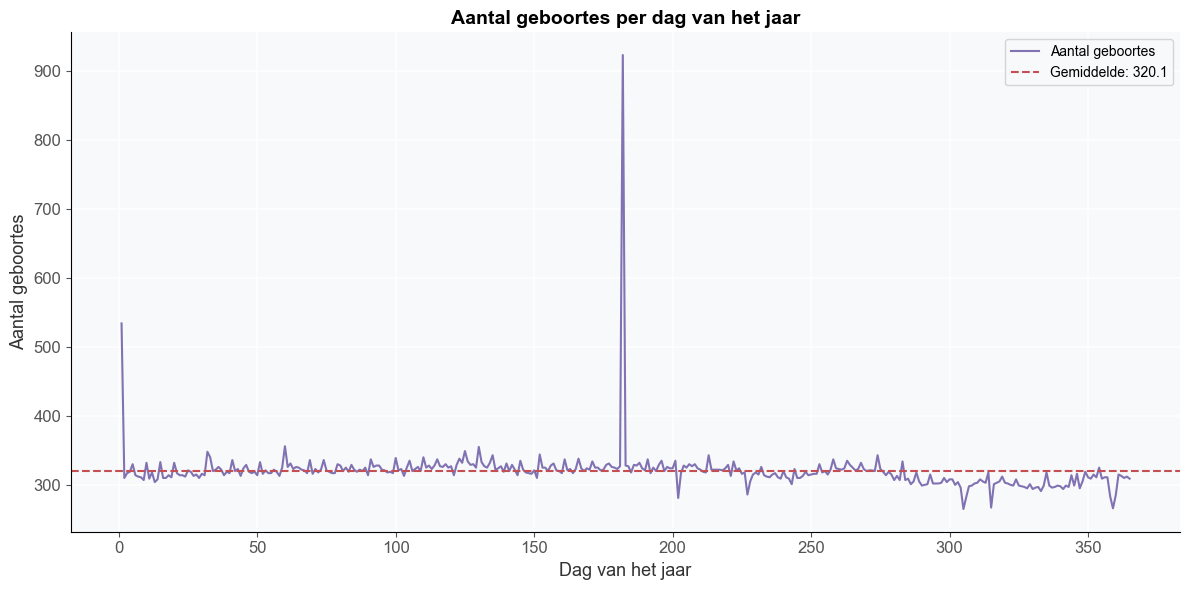

In [ ]:


geboortes_per_dag = df_births.groupby("dag van het jaar").size().reset_index(name="aantal_geboortes")
gemiddelde = geboortes_per_dag["aantal_geboortes"].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    geboortes_per_dag["dag van het jaar"],
    geboortes_per_dag["aantal_geboortes"],
    color=kleuren["paars"],
    label="Aantal geboortes"
)
ax.axhline(
    gemiddelde,
    color=kleuren["rood"],
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.1f}"
)
ax.set_title("Aantal geboortes per dag van het jaar")
ax.set_xlabel("Dag van het jaar")
ax.set_ylabel("Aantal geboortes")
ax.legend()
plt.tight_layout()
plt.show()

### Vraag 2: Outliers vinden & behandelen
#### Vraag 2.1 Zoek alle outliers in de dataset. (1 pnt)

Kies een regel om een datapunt als 'outlier' te classifieren, pas deze toe en verdedig je keuze.

In [ ]:
maximum = geboortes_per_dag["aantal_geboortes"].max()
minimum = geboortes_per_dag["aantal_geboortes"].min()



x = 70     # t.o.v. het gemiddelde


# bepaal de ondergrens voor de maxima
MaxLow = int(maximum - ((maximum - gemiddelde) *x/100))

# bepaal de bovengrens voor de minima
MinHigh = int(minimum + ((gemiddelde - minimum) *x/100))

df_MaxOutlier = geboortes_per_dag.loc[geboortes_per_dag["aantal_geboortes"] > MaxLow]
df_MinOutlier = geboortes_per_dag.loc[geboortes_per_dag["aantal_geboortes"] < MinHigh]
display(df_MaxOutlier)
display(df_MinOutlier)

#### Vraag 2.2 Outlier remediation (1 pnt)
Je stelt vast dat twee dagen eruit springen als outliers. Corrigeer en voeg foute rijen toe aan `df_wrong` met een duidelijk omschreven reden. Documenteer in een comment welk patroon je opmerkte en  verdedig je correctiestrategie. Hermaak ten slotte de figuur uit Vraag 1 op basis van `df_births_clean`.

Er zijn 2 dagen die er aan de bovenkant uitschieten. De entries van deze 2 dagen zullen eruit gehaald worden

In [16]:
outlier_dagen = df_MaxOutlier["dag van het jaar"].tolist()

# Masker: rijen waarvan de dag van het jaar een outlier is
masker_wrong = df_births["dag van het jaar"].isin(outlier_dagen)

# df_wrong: de foutieve rijen met uitleg
df_wrong = df_births[masker_wrong].copy()
df_wrong["reden"] = df_wrong["dag van het jaar"].map({
    1:   "Dag 1 (1 jan): 534 geboortes — uitschieter hoog (feestdageffect?)",
    182: "Dag 182 (1 jul): 923 geboortes — extreme uitschieter, ~3× normaal",
})

# df_births_clean: alles zonder de outlier-dagen
df_births_clean = df_births[~masker_wrong].reset_index(drop=True)

print(f"Rijen verwijderd : {masker_wrong.sum()}")
print(f"Rijen in clean   : {len(df_births_clean)}")


Rijen verwijderd : 1457
Rijen in clean   : 115393


In [25]:
df_wrong

,gemeente,naam,geslacht,verwachte datum,date,SourceFile,dag van het jaar,dag van de week,reden
0,Hooglede,Elias,Mannelijk,2019-01-14,2019-01-01,2019-1-1.csv,1,1,Dag 1 (1 jan): 534 geboortes — uitschieter hoo...
364,Scherpenheuvel-Zichem,Rudolphe,Mannelijk,2019-01-11,2019-01-01,2019-1-1.csv,1,1,Dag 1 (1 jan): 534 geboortes — uitschieter hoo...
363,Courcelles,Sarah,Vrouwelijk,2019-01-02,2019-01-01,2019-1-1.csv,1,1,Dag 1 (1 jan): 534 geboortes — uitschieter hoo...
362,Lille,Maria,Vrouwelijk,2018-12-31,2019-01-01,2019-1-1.csv,1,1,Dag 1 (1 jan): 534 geboortes — uitschieter hoo...
361,Koksijde,Martine,Vrouwelijk,2018-12-29,2019-01-01,2019-1-1.csv,1,1,Dag 1 (1 jan): 534 geboortes — uitschieter hoo...
...,...,...,...,...,...,...,...,...,...
87350,Aalst (Aalst),Paula,Vrouwelijk,2019-07-15,2019-07-01,2019-7-1.csv,182,0,Dag 182 (1 jul): 923 geboortes — extreme uitsc...
87349,Rotselaar,Johan,Mannelijk,2019-07-08,2019-07-01,2019-7-1.csv,182,0,Dag 182 (1 jul): 923 geboortes — extreme uitsc...
87348,Anderlecht,Jawad,Mannelijk,2019-07-24,2019-07-01,2019-7-1.csv,182,0,Dag 182 (1 jul): 923 geboortes — extreme uitsc...
87346,Borgworm,Daniel,Mannelijk,2019-07-03,2019-07-01,2019-7-1.csv,182,0,Dag 182 (1 jul): 923 geboortes — extreme uitsc...


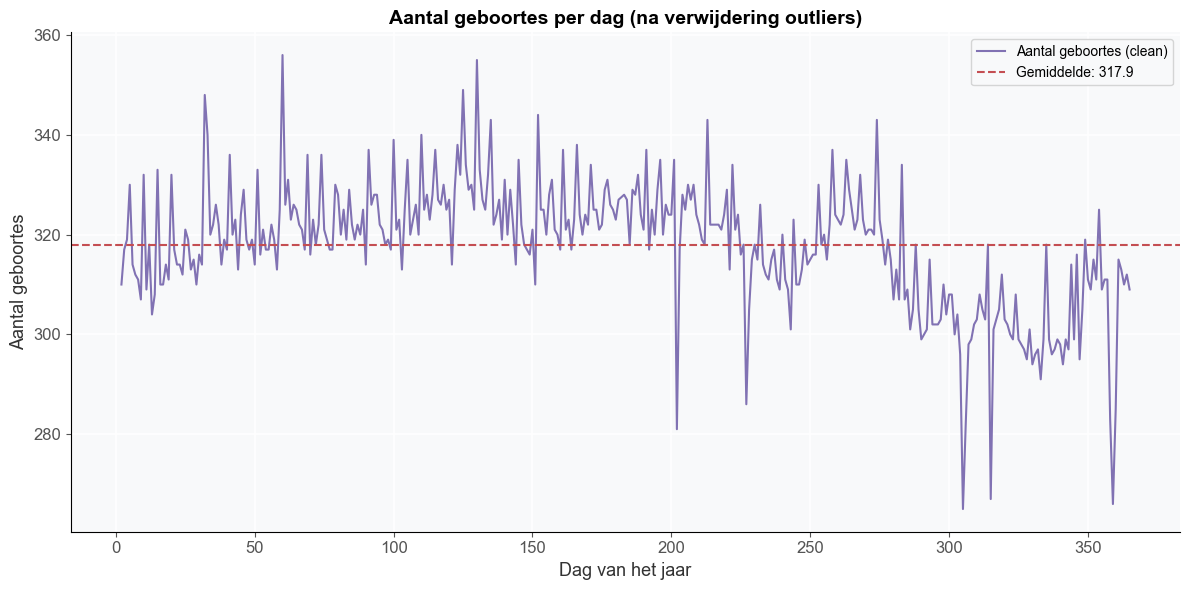

In [33]:
#Hermaak de figuur op basis van df_births_clean

outlier_dagenkleuren = config["Plot"]["kleuren"]

geboortes_clean = (
    df_births_clean
    .groupby(["dag van het jaar", "date"])
    .size()
    .reset_index(name="aantal_geboortes")
)
gemiddelde_clean = geboortes_clean["aantal_geboortes"].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    geboortes_clean["dag van het jaar"],
    geboortes_clean["aantal_geboortes"],
    color=kleuren["paars"],
    label="Aantal geboortes (clean)",
)
ax.axhline(
    gemiddelde_clean,
    color=kleuren["rood"],
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde_clean:.1f}",
)
ax.set_title("Aantal geboortes per dag (na verwijdering outliers)")
ax.set_xlabel("Dag van het jaar")
ax.set_ylabel("Aantal geboortes")
ax.legend()
plt.tight_layout()
plt.show()

In [42]:
#Stap 1 — Filter op de tweede helft van het jaar (dag 183–365)
geboortes_h2 = geboortes_clean[
    geboortes_clean["dag van het jaar"] >= 183
].copy()

#Stap 2 — Bereken de afwijking t.o.v. het gemiddelde (abs)
gemiddelde_h2 = geboortes_h2["aantal_geboortes"].mean()

geboortes_h2["afwijking"] = (
    geboortes_h2["aantal_geboortes"] - gemiddelde_h2
).abs()

# Selecteer de 8 meest extreme dagen
top8_extreme = (
    geboortes_h2
    .nlargest(8, "afwijking")
    .sort_values("date")
    [["dag van het jaar", "aantal_geboortes", "afwijking", "date"]]
)

display(top8_extreme)

,dag van het jaar,aantal_geboortes,afwijking,date
199,202,281,31.404372,2019-07-21
210,213,343,30.595628,2019-08-01
271,274,343,30.595628,2019-10-01
302,305,265,47.404372,2019-11-01
303,306,282,30.404372,2019-11-02
312,315,267,45.404372,2019-11-11
355,358,283,29.404372,2019-12-24
356,359,266,46.404372,2019-12-25


In [48]:
geboortes_clean[geboortes_clean["date"].dt.date == pd.Timestamp("2019-08-15").date()]

,dag van het jaar,date,aantal_geboortes
224,227,2019-08-15,286


### Vraag 3: Verbanden per week/maand

#### Vraag 3.1 (2 pnt)
We zien vele pieken en dalen in de evolutie van het aantal geboortes. We willen deze grafiek graag iets "gladder" maken. Kan je hiervoor eens een visualizatie maken van het **gemiddeld** aantal geboortes per week (dit voor elke week, dus maandag-maandag, dinsdag-dinsdag, woensdag-woensdag, ...).

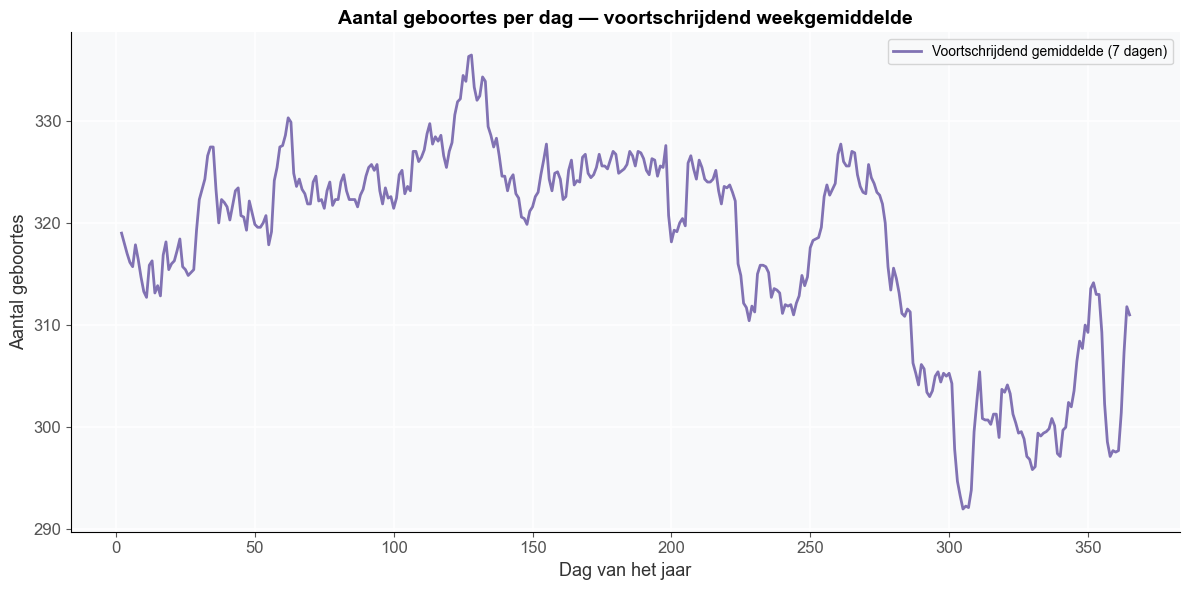

In [59]:
# "maandag-maandag, dinsdag-dinsdag, ..." betekent een voortschrijdend
# gemiddelde met venster = 7, gecentreerd op de dag zelf.
# center=True → 3 dagen voor + dag zelf + 3 dagen na.

geboortes_clean["gemiddelde_per_week"] = (
    geboortes_clean["aantal_geboortes"]
    .rolling(window=7, center=True, min_periods=1)
    .mean()
)



fig, ax = plt.subplots(figsize=(12, 6))



# Voortschrijdend weekgemiddelde
ax.plot(
    geboortes_clean["dag van het jaar"],
    geboortes_clean["gemiddelde_per_week"],
    color=kleuren["paars"],
    linewidth=2,
    label="Voortschrijdend gemiddelde (7 dagen)",
)



ax.set_title("Aantal geboortes per dag — voortschrijdend weekgemiddelde")
ax.set_xlabel("Dag van het jaar")
ax.set_ylabel("Aantal geboortes")
ax.legend()
plt.tight_layout()
plt.show()

#### Vraag 3.2 (2 pnt)
Dat ziet er al een stuk mooier uit!  We zien ook een aantal duidelijk dips & pieken verschijnen die we eerder niet zagen. We kunnen nu ook even kijken naar het gemiddeld aantal geboortes per dag van de week! Misschien worden er wel gewoon veel minder mensen geboren op zondag dan een andere dag?

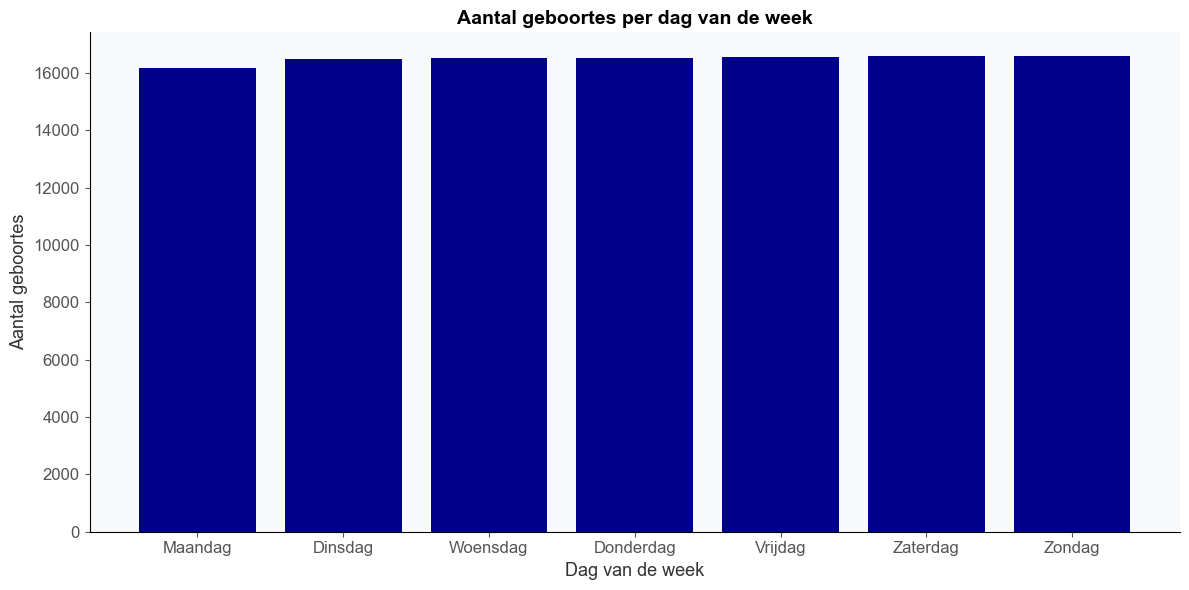

In [70]:
geboortes_per_weekdag = (
    df_births_clean
    .groupby("dag van de week")
    .size()
    .reset_index(name="aantal_geboortes")
)

dag_namen = ["Maandag", "Dinsdag", "Woensdag", "Donderdag", "Vrijdag", "Zaterdag", "Zondag"]
geboortes_per_weekdag["naam"] = geboortes_per_weekdag["dag van de week"].map(
    dict(enumerate(dag_namen))
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    geboortes_per_weekdag["naam"],
    geboortes_per_weekdag["aantal_geboortes"],
    color=kleuren["marineblauw"],
)

ax.set_title("Aantal geboortes per dag van de week")
ax.set_xlabel("Dag van de week")
ax.set_ylabel("Aantal geboortes")
ax.grid(False)
plt.tight_layout()
plt.show()

#### Vraag 3.3 — Maandverschillen in geboortes (3pnt)

Je beschikt over geboortecijfers per dag voor één kalenderjaar.

Maak één visualisatie die het gemiddeld aantal geboortes per maand toont
en tegelijk toelaat om de variatie binnen elke maand te vergelijken.

De visualisatie moet:
- de maanden tonen in chronologische volgorde (januari → december)
- per maand het gemiddelde aantal geboortes tonen (IK NEEM AAN GEMIDDELDE PER DAG)
- per maand de onzekerheid rond dat gemiddelde tonen op 95% betrouwbaarheid en gebaseerd op de dagwaarden (niet handmatig berekend)


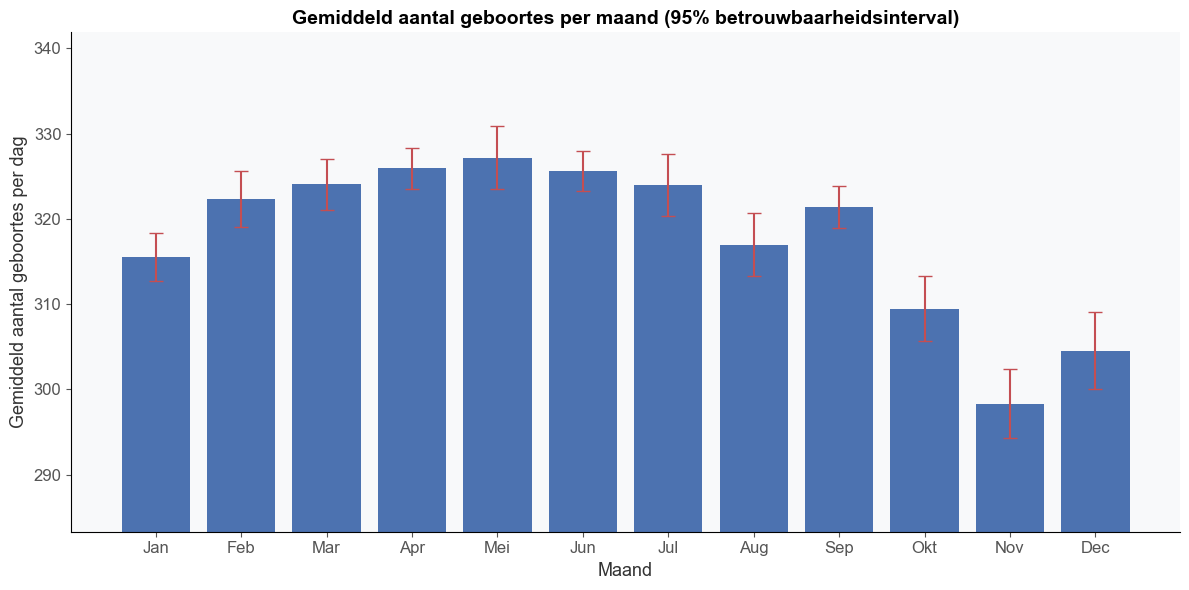

In [92]:
import numpy as np

# Voeg maandkolom toe op basis van de datum
df_births_clean["maand"] = df_births_clean["date"].dt.month

maand_namen = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun",
               "Jul", "Aug", "Sep", "Okt", "Nov", "Dec"]

# Stap 1: tel geboortes per dag én per maand
# → dagwaarden per maand als basis voor het BI
geboortes_per_dag_maand = (
    df_births_clean
    .groupby(["maand", "date"])
    .size()
    .reset_index(name="aantal_geboortes")
)

# Stap 2: bereken gemiddelde + 95% BI per maand
maand_stats = (
    geboortes_per_dag_maand
    .groupby("maand")["aantal_geboortes"]
    .apply(ci95)
    .unstack()
    .reset_index()
)

# Stap 3: plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    maand_namen,
    maand_stats["gemiddelde"],
    color=kleuren["primair"],
    zorder=2,
)

ax.errorbar(
    maand_namen,
    maand_stats["gemiddelde"],
    yerr=[
        maand_stats["gemiddelde"] - maand_stats["ci_laag"],
        maand_stats["ci_hoog"]    - maand_stats["gemiddelde"],
    ],
    fmt="none",
    color=kleuren["rood"],
    capsize=5,
    linewidth=1.5,
    zorder=3,
)

# Y-as beginnen net onder minimum zodat verschillen zichtbaar zijn
y_min = maand_stats["ci_laag"].min()
y_max = maand_stats["ci_hoog"].max()
marge = (y_max - y_min) * 0.3
ax.set_ylim(y_min - marge, y_max + marge)

ax.set_title("Gemiddeld aantal geboortes per maand (95% betrouwbaarheidsinterval)")
ax.set_xlabel("Maand")
ax.set_ylabel("Gemiddeld aantal geboortes per dag")
ax.grid(False)
plt.tight_layout()
plt.show()

Het zijn twee geneste functies — van binnen naar buiten:
1. np.random.standard_t(df=n-1, size=100_000)
Trek 100.000 willekeurige getallen uit een t-verdeling met n-1 vrijheidsgraden. Voor januari (n=31) is dat dus een t-verdeling met 30 vrijheidsgraden. Je krijgt een reeks van 100.000 waarden terug.
2. np.percentile(..., [2.5, 97.5])
Sorteer die 100.000 waarden en neem:

het 2.5e percentiel → de waarde waarbij 2.5% van de trekkingen lager ligt
het 97.5e percentiel → de waarde waarbij 97.5% van de trekkingen lager ligt

Het stuk daartussenin omvat dus 95% van alle waarden — dat zijn de grenzen van het 95% betrouwbaarheidsinterval.
Visueel:
|--2.5%--|--------95%--------|--2.5%--|
        t[0]               t[1]
       (~-2.04)           (~+2.04)
t is dus een lijst van twee waarden: [t[0], t[1]], de linker- en rechtergrens van de t-verdeling.

In [88]:
print(maand_stats.head())

   maand     level_1  aantal_geboortes
0      1  gemiddelde        315.533333
1      1     ci_laag        312.727349
2      1     ci_hoog        318.342243
3      2  gemiddelde        322.321429
4      2     ci_laag        319.089550


#### Vraag 3.2 Weekdag en seizoen (4 pnt)

Je beschikt over geboortecijfers per dag voor één kalenderjaar.

Onderzoek of het effect van de dag van de week op het aantal geboortes constant is doorheen het jaar of verschilt naargelang het seizoen.

Maak één visualisatie die:
- verschillen tussen weekdagen toont
- toelaat om deze verschillen over het jaar te vergelijken
- leesbaar blijft zonder aparte grafieken per maand of weekdag

C:\Users\kurtm\AppData\Local\Temp\ipykernel_10024\1087387965.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\kurtm\AppData\Local\Temp\ipykernel_10024\1087387965.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\kurtm\AppData\Local\Temp\ipykernel_10024\1087387965.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\kurtm\AppData\Local\Temp\ipykernel_10024\1087387965.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxpl

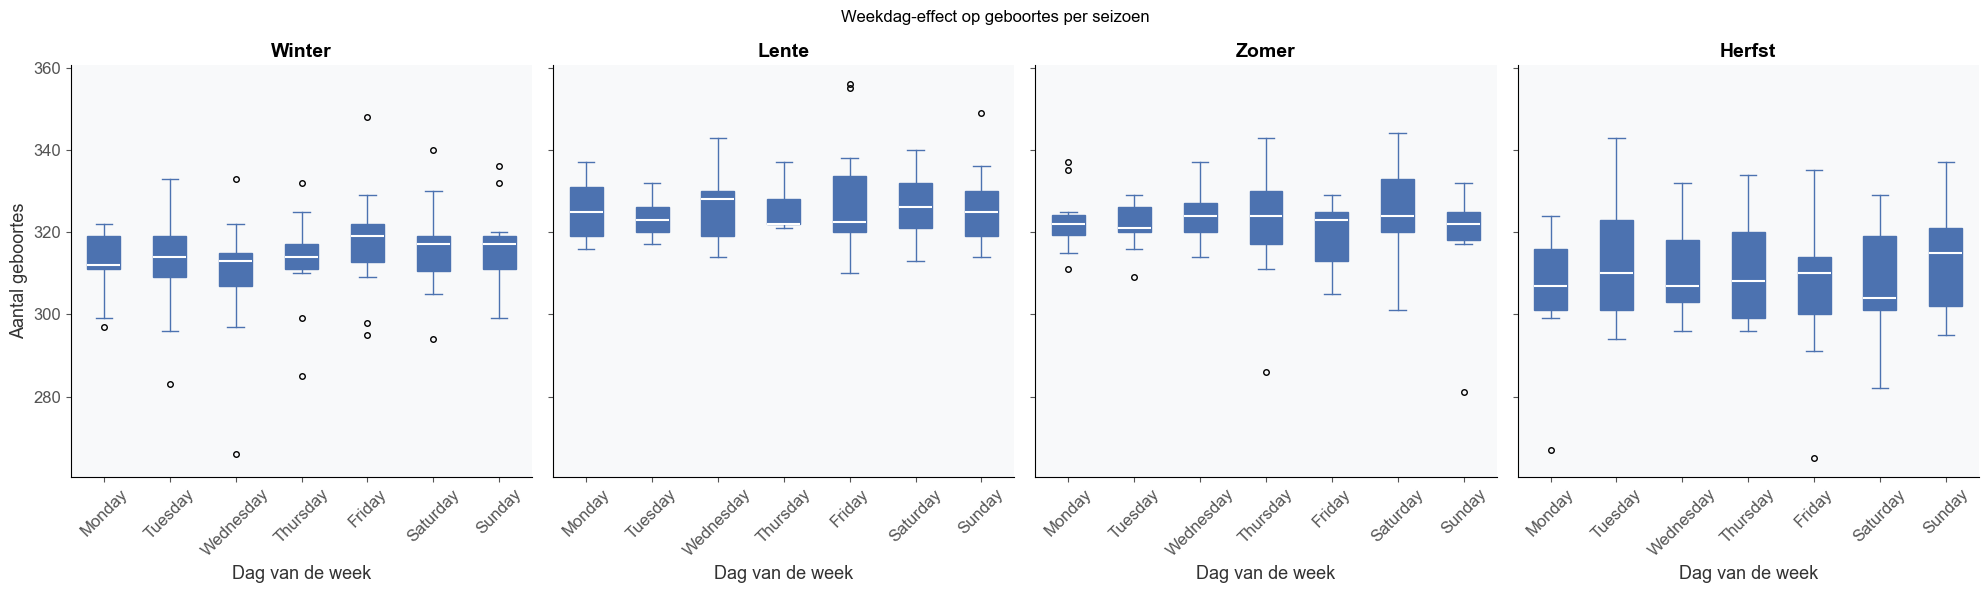

In [101]:

# Seizoen toewijzen op basis van maand
seizoen_map = {
    12: "Winter", 1: "Winter",  2: "Winter",
     3: "Lente",  4: "Lente",   5: "Lente",
     6: "Zomer",  7: "Zomer",   8: "Zomer",
     9: "Herfst", 10: "Herfst", 11: "Herfst",
}
df_births_clean["seizoen"] = df_births_clean["maand"].map(seizoen_map)

# Engelstalige namen want pandas dt.dayofweek geeft 0=Monday t.e.m. 6=Sunday
dag_namen = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Tel geboortes per combinatie van seizoen, weekdag en datum
# → elke rij is één dag met zijn totaal aantal geboortes
# → dit zijn de ruwe waarden waarover de boxplot wordt getekend
geboortes_per_dag = (
    df_births_clean
    .groupby(["seizoen", "dag van de week", "date"])
    .size()
    .reset_index(name="aantal_geboortes")
)

# Voeg leesbare weekdagnaam toe
geboortes_per_dag["weekdag_naam"] = geboortes_per_dag["dag van de week"].map(
    dict(enumerate(dag_namen))
)

# Volgorde van de seizoenen van links naar rechts in de grafiek
seizoen_volgorde = ["Winter", "Lente", "Zomer", "Herfst"]

# 4 subplots naast elkaar, gedeelde Y-as zodat seizoenen vergelijkbaar zijn
fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=True)

for ax, seizoen in zip(axes, seizoen_volgorde):

    # Filter op het huidige seizoen
    data = geboortes_per_dag[geboortes_per_dag["seizoen"] == seizoen]

    # Bouw een lijst van 7 arrays: één per weekdag (ma → zo)
    # boxplot verwacht een lijst van reeksen, niet een DataFrame
    boxdata = [
        data[data["dag van de week"] == i]["aantal_geboortes"].values
        for i in range(7)
    ]

    ax.boxplot(
        boxdata,
        labels=dag_namen,
        patch_artist=True,           # vul de boxen in met kleur
        boxprops=dict(facecolor=kleuren["primair"], color=kleuren["primair"]),
        medianprops=dict(color="white", linewidth=1.5),  # mediaan in wit
        whiskerprops=dict(color=kleuren["primair"]),     # snorharen
        capprops=dict(color=kleuren["primair"]),         # kapjes aan snorharen
        flierprops=dict(                                 # uitschieters
            marker="o",
            color=kleuren["primair"],
            markersize=4,
            markerfacecolor="none",  # open cirkels voor uitschieters
        ),
    )

    ax.set_title(seizoen)
    ax.set_xlabel("Dag van de week")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(False)

# Enkel de meest linkse subplot krijgt een Y-as label
# (sharey=True → de andere subplots delen dezelfde schaal)
axes[0].set_ylabel("Aantal geboortes")

fig.suptitle("Weekdag-effect op geboortes per seizoen")
plt.tight_layout()
plt.show()

In [99]:
seizoen_weekdag

,seizoen,dag van de week,aantal_geboortes,weekdag_naam
0,Herfst,0,3980,Ma
1,Herfst,1,4058,Di
2,Herfst,2,4036,Wo
3,Herfst,3,4046,Do
4,Herfst,4,3986,Vr
5,Herfst,5,4004,Za
6,Herfst,6,4074,Zo
7,Lente,0,4237,Ma
8,Lente,1,4199,Di
9,Lente,2,4242,Wo


## Stap 3: Onderzoeksvragen

### Onderzoek 1: Unisex namen

#### Vraag 1.1 (3pnt)
Je wil namen identificeren die zowel bij jongens als bij meisjes voorkomen.
Construeer een tabel `df_name_gender` met exact één rij per naam, waarin je het totaal aantal geboortes voor jongens, voor meisjes en in totaal opneemt.

Rapporteer het aantal namen dat bij beide geslachten voorkomt en geef voor deze groep telkens de drie namen met het hoogste aantal jongensgeboortes, meisjesgeboortes en totale geboortes. Licht kort toe of en waarom je zeldzame namen al dan niet meeneemt in de analyse.

In [125]:
# Stap 1: tel geboortes per naam én geslacht
naam_geslacht = (
    df_births_clean
    .groupby(["naam", "geslacht"])
    .size()
    .reset_index(name="aantal")
)

# Stap 2: pivot zodat jongens en meisjes aparte kolommen worden
df_name_gender = (
    naam_geslacht
    .pivot_table(index="naam", columns="geslacht", values="aantal", fill_value=0)
    .reset_index()
)

# Kolomnamen leesbaar maken — afhankelijk van hoe geslacht gecodeerd is in de data
# (pas "M"/"F" aan naar de werkelijke waarden in jouw dataset)
df_name_gender.columns.name = None
df_name_gender = df_name_gender.rename(columns={"Mannelijk": "jongens", "Vrouwelijk": "meisjes"})

# Expliciete cast naar int (pivot_table geeft soms floats terug door fill_value)
df_name_gender["jongens"] = df_name_gender["jongens"].astype(int)
df_name_gender["meisjes"] = df_name_gender["meisjes"].astype(int)

# Stap 3: totaal per naam
df_name_gender["totaal"] = df_name_gender["jongens"] + df_name_gender["meisjes"]

# Stap 4: namen die bij BEIDE geslachten voorkomen
# → zowel jongens als meisjes > 0
df_beide = df_name_gender[
    (df_name_gender["jongens"] > 0) & (df_name_gender["meisjes"] > 0)
].copy()



print(f"Aantal namen bij beide geslachten: {len(df_beide)}")

# Stap 5: top 3 per criterium
print("\nTop 3 hoogste jongensgeboortes:")
display(df_beide.nlargest(3, "jongens")[["naam", "jongens", "meisjes", "totaal"]])

print("\nTop 3 hoogste meisjesgeboortes:")
display(df_beide.nlargest(3, "meisjes")[["naam", "jongens", "meisjes", "totaal"]])

print("\nTop 3 hoogste totale geboortes:")
display(df_beide.nlargest(3, "totaal")[["naam", "jongens", "meisjes", "totaal"]])

Aantal namen bij beide geslachten: 75

Top 3 hoogste jongensgeboortes:


,naam,jongens,meisjes,totaal
3355,Maxime,200,6,206
4191,Robin,181,8,189
949,Claude,165,7,172



Top 3 hoogste meisjesgeboortes:


,naam,jongens,meisjes,totaal
1157,Dominique,160,229,389
794,Camille,7,160,167
2648,Kim,31,113,144



Top 3 hoogste totale geboortes:


,naam,jongens,meisjes,totaal
1157,Dominique,160,229,389
3355,Maxime,200,6,206
4191,Robin,181,8,189


Zeldzame namen: ze worden meegenomen in de analyse. Een naam die één keer bij een jongen en één keer bij een meisje voorkomt, kan een registratiefout zijn of een echte uniseksenaam — dat onderscheid is zonder extra context niet te maken. Door ze mee te nemen in df_name_gender maar apart te rapporteren via de top-3, blijft de tabel volledig terwijl de zeldzame gevallen de conclusies niet vertekenen.

In [124]:
df_beide

,naam,jongens,meisjes,totaal
75,Adama,1,3,4
196,Alexis,67,1,68
272,Amel,1,12,13
281,Amine,32,1,33
314,Andrea,22,46,68
...,...,...,...,...
5064,Yan,1,1,2
5071,Yannick,93,1,94
5104,Yentl,1,7,8
5106,Yi,1,1,2


#### Vraag 1.2 (2 pnt)

Niet alle namen die bij beide geslachten voorkomen, zijn evenwichtig verdeeld. In deze oefening beschouwen we een naam als “echt unisex” wanneer het aantal geboortes bij het ene geslacht niet meer dan 50% hoger ligt dan bij het andere. Concreet geldt voor een naam met `x` mannen en `y` vrouwen dat deze als echt unisex wordt beschouwd wanneer `x <= 1.5 * y` en `y <= 1.5 * x`.

Pas deze definitie toe op je unisex dataset en construeer een DataFrame `df_real_unisex` dat uitsluitend deze echte unisex namen bevat.

Beantwoord vervolgens opnieuw de drie vragen uit de vorige oefening voor deze dataset.

In [126]:
# Stap 1: filter op echte unisex namen
# een naam is echt unisex als x <= 1.5 * y én y <= 1.5 * x
df_real_unisex = df_beide[
    (df_beide["jongens"] <= 1.5 * df_beide["meisjes"]) &
    (df_beide["meisjes"] <= 1.5 * df_beide["jongens"])
].copy()

print(f"Aantal echte unisex namen: {len(df_real_unisex)}")

# Stap 2: top 3 per criterium
print("\nTop 3 hoogste jongensgeboortes:")
display(df_real_unisex.nlargest(3, "jongens")[["naam", "jongens", "meisjes", "totaal"]])

print("\nTop 3 hoogste meisjesgeboortes:")
display(df_real_unisex.nlargest(3, "meisjes")[["naam", "jongens", "meisjes", "totaal"]])

print("\nTop 3 hoogste totale geboortes:")
display(df_real_unisex.nlargest(3, "totaal")[["naam", "jongens", "meisjes", "totaal"]])

Aantal echte unisex namen: 15

Top 3 hoogste jongensgeboortes:


,naam,jongens,meisjes,totaal
1157,Dominique,160,229,389
3780,Noa,36,26,62
883,Charlie,6,4,10



Top 3 hoogste meisjesgeboortes:


,naam,jongens,meisjes,totaal
1157,Dominique,160,229,389
3780,Noa,36,26,62
883,Charlie,6,4,10



Top 3 hoogste totale geboortes:


,naam,jongens,meisjes,totaal
1157,Dominique,160,229,389
3780,Noa,36,26,62
883,Charlie,6,4,10


#### Vraag 1.3 (1 pnt)
Ga na of echte unisex namen relatief populairder zijn bij mannen of bij vrouwen, of dat de populariteit tussen beide geslachten vergelijkbaar is. Hiervoor kan je vertrekken van het percentage mannen en vrouwen dat een echte unisex naam draagt.

In [132]:
# Totaal aantal geboortes per geslacht in de volledige dataset
totaal_jongens = (df_births_clean["geslacht"] == "Mannelijk").sum()
totaal_meisjes = (df_births_clean["geslacht"] == "Vrouwelijk").sum()

# Aantal geboortes met een echte unisex naam per geslacht
unisex_jongens = df_real_unisex["jongens"].sum()
unisex_meisjes = df_real_unisex["meisjes"].sum()

# Percentage van alle jongens/meisjes dat een echte unisex naam draagt
pct_jongens = unisex_jongens / totaal_jongens * 100
pct_meisjes = unisex_meisjes / totaal_meisjes * 100

print(f"Totaal jongens              : {totaal_jongens:>8}")
print(f"Totaal meisjes              : {totaal_meisjes:>8}")
print(f"Jongens met unisex naam     : {unisex_jongens:>8}  ({pct_jongens:.2f}%)")
print(f"Meisjes met unisex naam     : {unisex_meisjes:>8}  ({pct_meisjes:.2f}%)")

Totaal jongens              :    58202
Totaal meisjes              :    57191
Jongens met unisex naam     :      231  (0.40%)
Meisjes met unisex naam     :      287  (0.50%)


In [130]:
totaal_jongens

58202

#### Vraag 1.4 (2 pnt)

Maak een visualizatie die alle echte unisex namen toont en de relatieve voorkomens bij mannen en vrouwen.

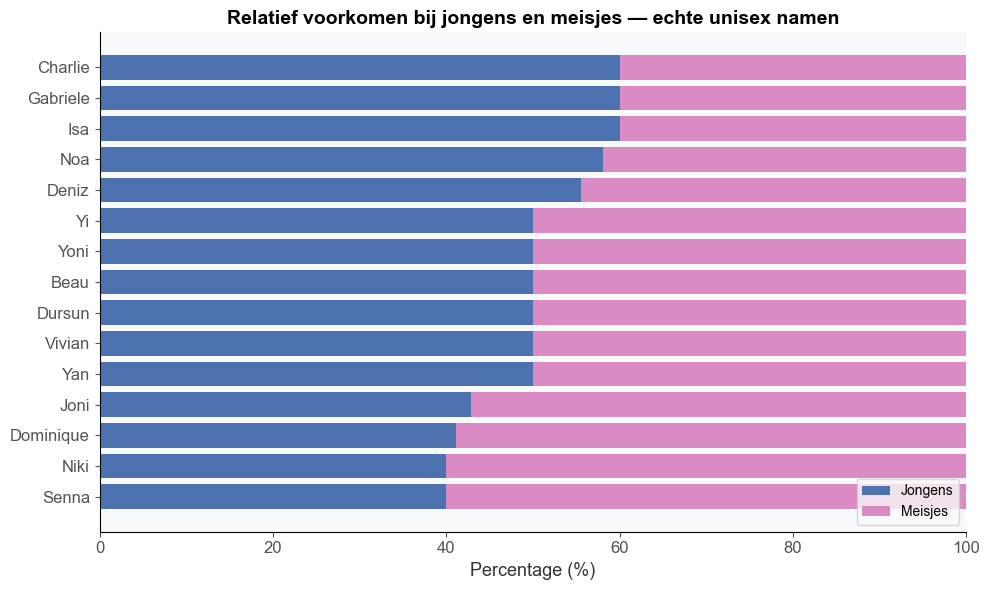

In [134]:
# Bereken ratio: aandeel jongens binnen de unisex naam
df_real_unisex["pct_jongens"] = (
    df_real_unisex["jongens"] / df_real_unisex["totaal"] * 100
)

# Sorteer op pct_jongens zodat de grafiek leesbaar is van vrouwelijkst → mannelijkst
df_plot = df_real_unisex.sort_values("pct_jongens")

fig, ax = plt.subplots(figsize=(10, len(df_plot) * 0.4))

# Gestapelde horizontale balkjes: meisjes links, jongens rechts
ax.barh(
    df_plot["naam"],
    df_plot["pct_jongens"],
    color=kleuren["primair"],
    label="Jongens",
)
ax.barh(
    df_plot["naam"],
    100 - df_plot["pct_jongens"],
    left=df_plot["pct_jongens"],
    color=kleuren["roze"],
    label="Meisjes",
)

# Verticale lijn op 50% — perfect evenwicht
# ax.axvline(50, color=kleuren["rood"], linestyle="--", linewidth=1)

ax.set_xlim(0, 100)
ax.set_xlabel("Percentage (%)")
ax.set_title("Relatief voorkomen bij jongens en meisjes — echte unisex namen")
ax.legend(loc="lower right")
ax.grid(False)
plt.tight_layout()
plt.show()

### Onderzoek 2: de accuraatheid van de geschatte bevallingsdatum

### Vraag 2.1 Evolutie vergelijken (3pnt)

Maak één figuur waarin je het totale aantal effectieve geboortes per dag en het totale aantal verwachte geboortes per dag samen weergeeft over de tijd.

Zorg ervoor dat beide reeksen op een eerlijke en vergelijkbare manier worden getoond.

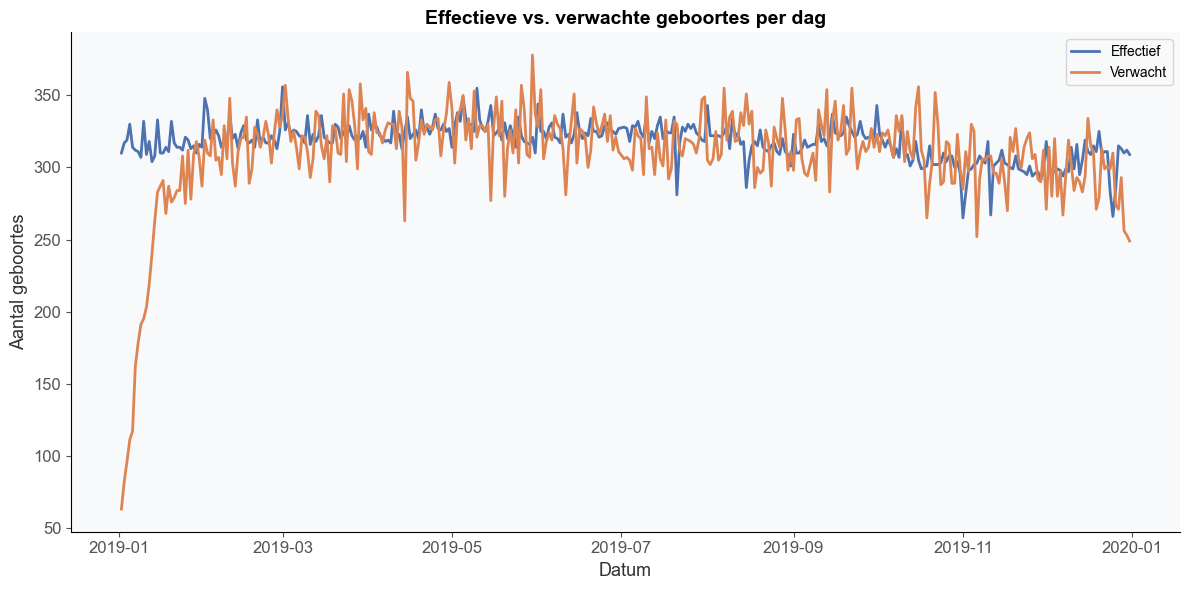

In [143]:
# Totaal effectieve geboortes per dag (date)
effectief = (
    df_births_clean
    .groupby("date")
    .size()
    .reset_index(name="effectief")
)

# Totaal verwachte geboortes per dag (verwachte datum)
verwacht = (
    df_births_clean
    .groupby("verwachte datum")
    .size()
    .reset_index(name="verwacht")
)

# Combineer beide reeksen op datum
evolutie = effectief.merge(
    verwacht,
    left_on="date",
    right_on="verwachte datum",
    how="outer",
).sort_values("date")

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(evolutie["date"], evolutie["effectief"],
        color=kleuren["primair"], linewidth=2, label="Effectief")
ax.plot(evolutie["date"], evolutie["verwacht"],
        color=kleuren["secundair"], linewidth=2, label="Verwacht")

ax.set_title("Effectieve vs. verwachte geboortes per dag")
ax.set_xlabel("Datum")
ax.set_ylabel("Aantal geboortes")
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

In [139]:
df_births_clean.dtypes

gemeente                       str
naam                           str
geslacht                       str
verwachte datum     datetime64[us]
date                datetime64[us]
SourceFile                     str
dag van het jaar             int32
dag van de week              int32
maand                        int32
seizoen                        str
dtype: object


#### Vraag 2.2 (1 pnt)
De figuur vertoont aan het begin en het einde van het jaar een afwijkend patroon. Beschrijf kort waarom dit gebeurt en noteer je verklaring in een comment




Dat is een randeffect: aan het begin en einde van het jaar zijn de verwachte en effectieve datums het meest uit elkaar.
De reden: een baby die effectief geboren wordt op dag 1 (1 januari) had een verwachte datum die weken eerder lag — dus in het vorige jaar, buiten jouw dataset. Die verwachte geboortes ontbreken aan het begin.
Omgekeerd aan het einde: baby's verwacht op dag 350-365 kunnen effectief pas geboren worden in januari van het volgende jaar — die effectieve geboortes ontbreken aan het einde.

### Vraag 2.3 (3 pnt)

Voor het jaar 2019 wil je analyseren hoe vroeg baby’s effectief geboren worden ten opzichte van hun verwachte geboortedatum.

Definieer een foutmaat die het verschil uitdrukt tussen de effectieve en de verwachte geboortedag, waarbij positieve waarden overeenkomen met een geboorte vóór de verwachte datum. Beperk je analyse tot geboortes die effectief te vroeg plaatsvinden en visualiseer de verdeling van deze foutmaat voor 2019 in een histogram. Kies het aantal bins expliciet en motiveer kort waarom deze keuze geschikt is.

Duid in het histogram zowel de mediaan als het 90e percentiel van het aantal dagen te vroeg expliciet aan.

Mediaan dagen te vroeg : 7
90e percentiel         : 22


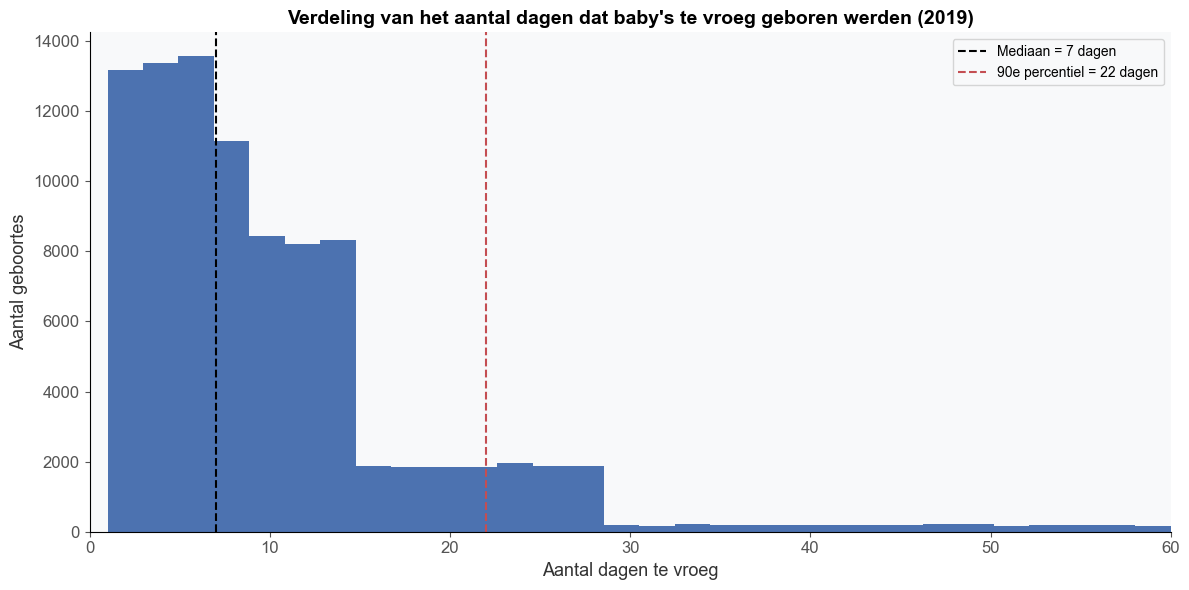

In [149]:
# Foutmaat: verwachte datum - effectieve datum
# positief = te vroeg geboren, negatief = te laat geboren
df_births_clean["dagen_te_vroeg"] = (
    df_births_clean["verwachte datum"] - df_births_clean["date"]
).dt.days

# Beperk tot enkel te vroeg geboren (positieve waarden)
df_vroeg = df_births_clean[df_births_clean["dagen_te_vroeg"] > 0].copy()

# Statistieken
mediaan = df_vroeg["dagen_te_vroeg"].median()
p90     = df_vroeg["dagen_te_vroeg"].quantile(0.90)

print(f"Mediaan dagen te vroeg : {mediaan:.0f}")
print(f"90e percentiel         : {p90:.0f}")

# Bins per 2 dagen → balans tussen granulariteit en leesbaarheid
# 1 bin per dag geeft te smalle balkjes, per week te grof
n_bins = int(df_vroeg["dagen_te_vroeg"].max()) // 2

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    df_vroeg["dagen_te_vroeg"],
    bins=n_bins,
    color=kleuren["primair"],
    edgecolor="none",
)

# Mediaan
ax.axvline(mediaan, color="black", linestyle="--", linewidth=1.5,
           label=f"Mediaan = {mediaan:.0f} dagen")

# 90e percentiel
ax.axvline(p90, color=kleuren["rood"], linestyle="--", linewidth=1.5,
           label=f"90e percentiel = {p90:.0f} dagen")

ax.set_xlim(0, 60)
ax.set_title("Verdeling van het aantal dagen dat baby's te vroeg geboren werden (2019)")
ax.set_xlabel("Aantal dagen te vroeg")
ax.set_ylabel("Aantal geboortes")
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

### Vraag 2.4 (4 pnt)

Voor het jaar 2019 wil je nagaan hoe goed de verwachte geboortedag overeenkomt met de effectieve geboortedag, maar je wil dit nu enkel doen voor de acht gemeenten met het hoogste aantal geboortes.

Bepaal eerst welke acht gemeenten in 2019 de meeste geboortes tellen. Visualiseer vervolgens, voor deze acht gemeenten, de relatie tussen de effectieve dag van het jaar en de verwachte dag van het jaar in een scatterplot per gemeente, zodat je kan vergelijken of de accuraatheid verschilt tussen gemeenten.

Gebruik in alle deelplots dezelfde schaal op beide assen en voeg een referentielijn toe die een perfecte schatting voorstelt.

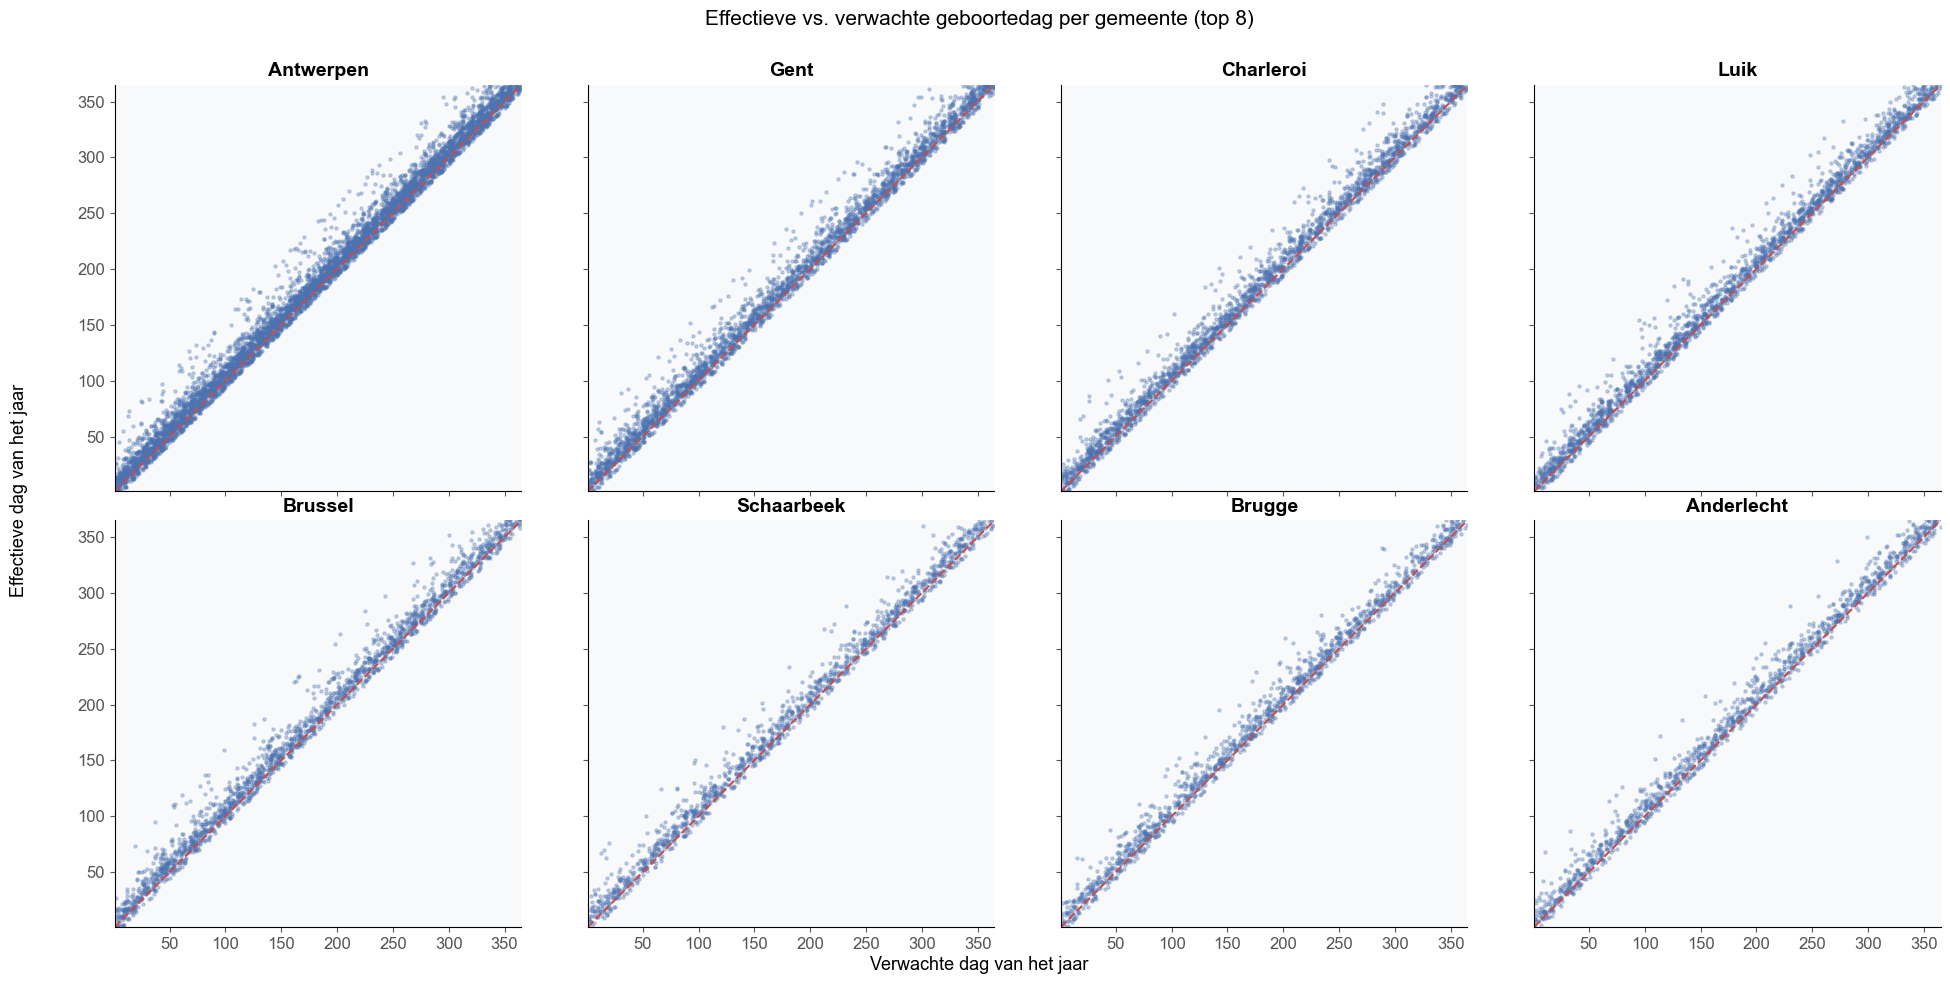

In [159]:
# Stap 1: bepaal de 8 gemeenten met de meeste geboortes
top8_gemeenten = (
    df_births_clean
    .groupby("gemeente")
    .size()
    .nlargest(8)
    .index
    .tolist()
)

# Stap 2: filter dataset op deze 8 gemeenten
df_top8 = df_births_clean[df_births_clean["gemeente"].isin(top8_gemeenten)].copy()

# Filter: enkel geboortes waarbij de verwachte datum ook in hetzelfde jaar valt
df_top8 = df_top8[
    df_top8["verwachte datum"].dt.year == df_top8["date"].dt.year
].copy()

# Stap 3: verwachte dag van het jaar toevoegen
df_top8["verwachte dag van het jaar"] = df_top8["verwachte datum"].dt.dayofyear

# Grenzen voor de assen (zelfde voor alle subplots)
as_min = 1
as_max = 365

fig, axes = plt.subplots(2,4,  figsize=(20, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, gemeente in zip(axes, top8_gemeenten):
    data = df_top8[df_top8["gemeente"] == gemeente]

    # Scatterplot: effectief vs verwacht
    ax.scatter(
        data["dag van het jaar"],
        data["verwachte dag van het jaar"],        
        color=kleuren["primair"],
        alpha=0.3,
        s=5,
    )

    # Referentielijn: perfecte schatting (effectief = verwacht)
    ax.plot(
        [as_min, as_max],
        [as_min, as_max],
        color=kleuren["rood"],
        linewidth=1.5,
        linestyle="--",
        label="Perfecte schatting",
    )

    ax.set_title(gemeente)
    ax.set_xlim(as_min, as_max)
    ax.set_ylim(as_min, as_max)
    ax.set_aspect("equal")
    ax.grid(False)

# Gedeelde aslabels
fig.text(0.5, 0.02, "Verwachte dag van het jaar",
         ha="center", fontsize=13)
fig.text(0.02, 0.5, "Effectieve dag van het jaar",
         ha="center", va="center", rotation="vertical", fontsize=13)

fig.suptitle("Effectieve vs. verwachte geboortedag per gemeente (top 8)", fontsize=15)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.97])
plt.show()

In [155]:
df_top8 = df_births_clean[df_births_clean["gemeente"].isin(top8_gemeenten)].copy()
df_top8

,gemeente,naam,geslacht,verwachte datum,date,SourceFile,dag van het jaar,dag van de week,maand,seizoen,verwachte dag van het jaar,dagen_te_vroeg
6,Antwerpen,Bart,Mannelijk,2019-01-25,2019-01-02,2019-1-2.csv,2,2,1,Winter,25,23
16,Antwerpen,Fatima,Vrouwelijk,2019-01-07,2019-01-02,2019-1-2.csv,2,2,1,Winter,7,5
25,Antwerpen,René,Mannelijk,2019-01-03,2019-01-02,2019-1-2.csv,2,2,1,Winter,3,1
30,Charleroi,Sophie,Vrouwelijk,2019-01-15,2019-01-02,2019-1-2.csv,2,2,1,Winter,15,13
47,Brugge,Elsa,Vrouwelijk,2018-12-29,2019-01-02,2019-1-2.csv,2,2,1,Winter,363,-4
...,...,...,...,...,...,...,...,...,...,...,...,...
115351,Brussel,Meliha,Vrouwelijk,2020-01-06,2019-12-31,2019-12-31.csv,365,1,12,Winter,6,6
115364,Antwerpen,Gino,Mannelijk,2020-01-01,2019-12-31,2019-12-31.csv,365,1,12,Winter,1,1
115375,Antwerpen,Celina,Vrouwelijk,2020-01-05,2019-12-31,2019-12-31.csv,365,1,12,Winter,5,5
115379,Charleroi,Youssef,Mannelijk,2020-01-09,2019-12-31,2019-12-31.csv,365,1,12,Winter,9,9


### Onderzoek 3: Aantal namen versus aantal babies

#### Vraag 3.1

Wanneer er meer baby’s geboren worden, verwachten we ook meer verschillende namen te observeren. Bij lage aantallen geboortes lijkt het aannemelijk dat dit verband ongeveer lineair is, maar bij grotere aantallen wordt het minder vanzelfsprekend dat het aantal unieke namen in dezelfde mate blijft toenemen. We verwachten bijvoorbeeld niet dat het aantal unieke namen bij twee miljoen geboortes dubbel zo groot is als bij één miljoen geboortes.

Onderzoek op basis van deze dataset het verband tussen het aantal baby’s en het aantal unieke namen. Je krijgt geen suggestie voor een specifieke visualisatie en kiest zelf hoe je dit verband het best aantoont.

Onderbouw je antwoord met minstens één visualisatie en bijkomende analyse waar nodig. Probeer niet enkel te beschrijven wat je ziet, maar overtuig waarom jouw conclusie logisch is gegeven de data en waarom een lineair verband al dan niet houdbaar blijft over het volledige bereik.

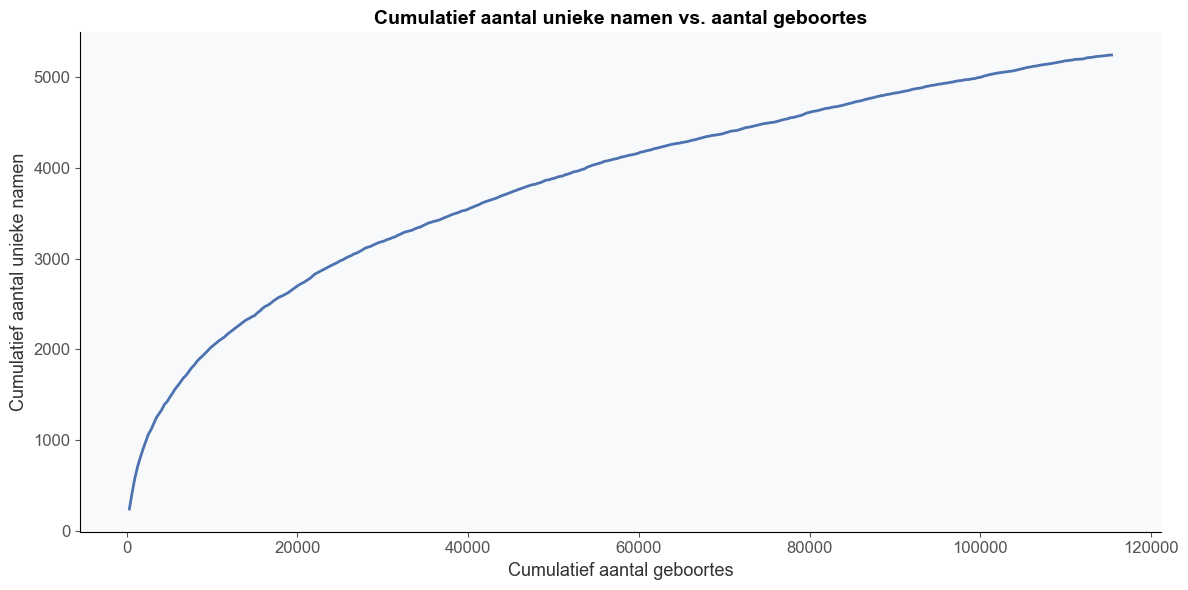

In [177]:
# Pivot: rijen = namen, kolommen = dag van het jaar, waarden = aantal geboortes
df_naam_dag = (
    df_births_clean
    .groupby(["naam", "dag van het jaar"])
    .size()
    .unstack(fill_value=0)
)

# Cumulatieve som over de dagen (axis=1 = over de kolommen, dus over de tijd)
df_naam_dag_cum = df_naam_dag.cumsum(axis=1)

# Cumulatief aantal unieke namen per dag
cum_unieke_namen = (df_naam_dag_cum > 0).sum(axis=0)

# Cumulatief totaal aantal geboortes per dag
cum_geboortes = df_naam_dag_cum.sum(axis=0)

# Combineer in één DataFrame
df_cumulatief = pd.DataFrame({
    "cum_unieke_namen": cum_unieke_namen.values,
    "cum_geboortes":    cum_geboortes.values,
})

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df_cumulatief["cum_geboortes"],
    df_cumulatief["cum_unieke_namen"],
    color=kleuren["primair"],
    linewidth=2,
)

ax.set_title("Cumulatief aantal unieke namen vs. aantal geboortes")
ax.set_xlabel("Cumulatief aantal geboortes")
ax.set_ylabel("Cumulatief aantal unieke namen")
ax.grid(False)
plt.tight_layout()
plt.show()



In [178]:
df_naam_dag_cum

dag van het jaar,2,3,4,5,6,7,8,9,10,11,...,356,357,358,359,360,361,362,363,364,365
naam,,,,,,,,,,,,,,,,,,,,,
Aaron,0,0,0,2,2,2,2,2,3,3,...,43,44,44,44,44,45,45,45,45,45
Aaya,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
Abbas,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2
Abdallah,0,0,0,0,0,0,0,0,0,0,...,3,3,3,3,3,3,3,3,3,3
Abdel,0,0,0,0,0,0,0,0,0,0,...,4,4,4,4,4,4,4,4,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Özge,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2
Özgür,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2
Özkan,0,0,0,0,1,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2


In [175]:
df_cumulatief

,cum_unieke_namen,cum_geboortes
0,246,310
1,423,627
2,583,946
3,713,1276
4,813,1590
...,...,...
358,5225,114149
359,5229,114462
360,5231,114772
361,5236,115084


Een afgeleide variabele (die misschien wel interessanter is) is de frequentie van elke naam als functie van het aantal geboortes. Als we deze variabele nemen, zien we vrij snel een lineair verband ontstaan (hoewel voor minder dan 10 000 geboortes het verband niet echt lineair is). We kunnen dit verband tonen en een lineaire rechte fitten op het gedeelte met meer dan 10 000 geboortes.

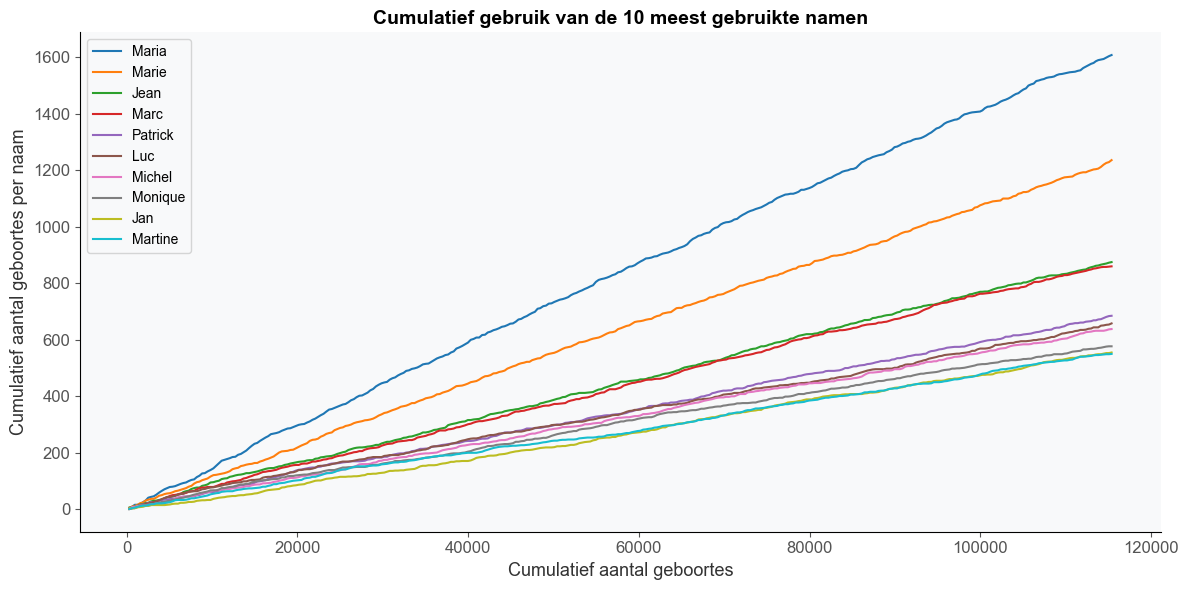

In [184]:
# Top 10 meest gebruikte namen over het volledige jaar (laatste kolom = cumulatief totaal)
top10_namen = (
    df_naam_dag_cum
    .iloc[:, -1]
    .nlargest(10)
    .index
    .tolist()
)

# Filter op top 10
df_top10 = df_naam_dag_cum.loc[top10_namen]

fig, ax = plt.subplots(figsize=(12, 6))

for naam in top10_namen:
    ax.plot(
        cum_geboortes.values,   # X-as = cumulatief aantal geboortes
        df_top10.loc[naam],
        linewidth=1.5,
        label=naam,
    )

ax.set_title("Cumulatief gebruik van de 10 meest gebruikte namen")
ax.set_xlabel("Cumulatief aantal geboortes")
ax.set_ylabel("Cumulatief aantal geboortes per naam")
ax.legend(loc="upper left")
ax.grid(False)
plt.tight_layout()
plt.show()

Met random sampling


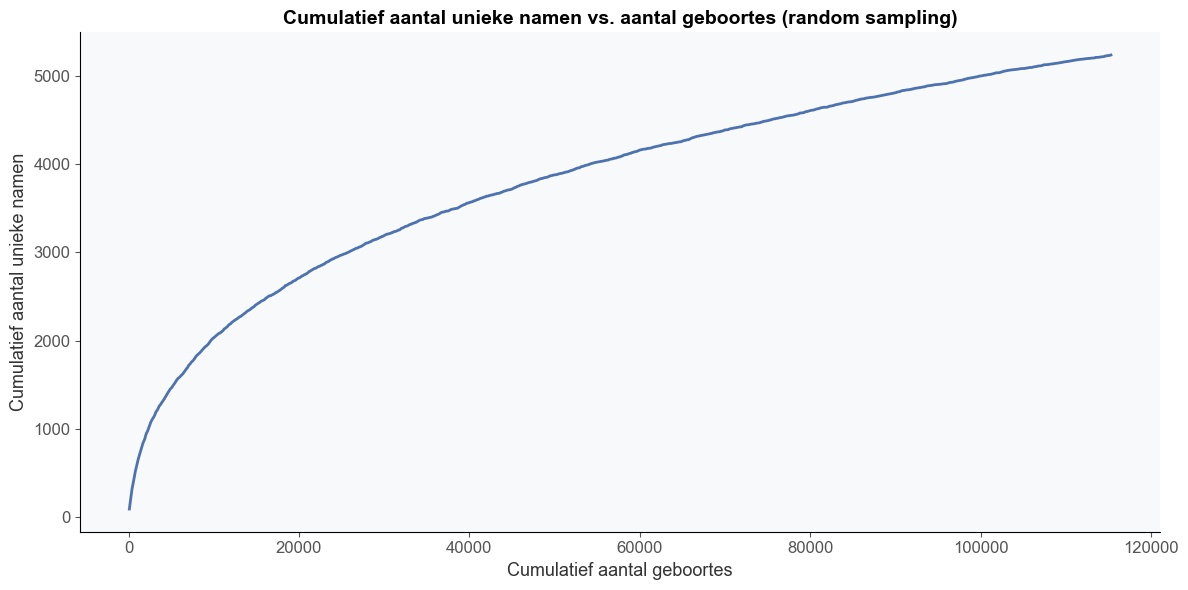

In [183]:
# Alle geboortes in willekeurige volgorde
df_shuffled = df_births_clean.sample(frac=1, random_state=42).reset_index(drop=True)

# Stappen van 100 geboortes
stappen = range(100, len(df_shuffled) + 1, 100)

records = []
for n in stappen:
    subset = df_shuffled.iloc[:n]
    records.append({
        "cum_geboortes":    n,
        "cum_unieke_namen": subset["naam"].nunique(),
    })

df_cumulatief = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df_cumulatief["cum_geboortes"],
    df_cumulatief["cum_unieke_namen"],
    color=kleuren["primair"],
    linewidth=2,
)

ax.set_title("Cumulatief aantal unieke namen vs. aantal geboortes (random sampling)")
ax.set_xlabel("Cumulatief aantal geboortes")
ax.set_ylabel("Cumulatief aantal unieke namen")
ax.grid(False)
plt.tight_layout()
plt.show()

# Functies

In [89]:
def ci95(x):
    """
    Berekent het gemiddelde en 95% betrouwbaarheidsinterval
    op basis van de t-verdeling, zonder scipy.
    """
    n   = len(x)
    gem = x.mean()

    # Standaardfout van het gemiddelde: s / √n
    se = x.std(ddof=1) / n**0.5

    # t-kritische waarde via Monte Carlo:
    # trek 100.000 waarden uit t-verdeling met n-1 vrijheidsgraden
    # → 2.5e en 97.5e percentiel geven de grenzen van het 95% BI
    t = np.percentile(
        np.random.standard_t(df=n - 1, size=100_000), [2.5, 97.5]
    )

    # BI = gemiddelde ± t * se
    # t[0] negatief → ondergrens, t[1] positief → bovengrens
    return pd.Series({
        "gemiddelde": gem,
        "ci_laag":    gem + t[0] * se,
        "ci_hoog":    gem + t[1] * se,
    })

In [3]:
def is_geldige_datum(datum: str) -> bool:
    try:
        datetime.strptime(datum, '%Y-%m-%d')
        return True
    except ValueError:
        return False

def volgende_geldige_datum(datum: str) -> str:
    jaar, maand, dag = map(int, datum.split('-'))
    try:
        return date(jaar, maand, dag).strftime('%Y-%m-%d')
    except ValueError:
        if maand == 12:
            maand = 1
            jaar += 1
        else:
            maand += 1
        return date(jaar, maand, 1).strftime('%Y-%m-%d')

def laatste_geldige_datum(datum: str) -> str:
    jaar, maand, dag = map(int, datum.split('-'))
    laatste_dag = calendar.monthrange(jaar, maand)[1]
    geldige_dag = min(dag, laatste_dag)
    return date(jaar, maand, geldige_dag).strftime('%Y-%m-%d')

In [2]:
# inlezen configfile

def load_project_config(config_path):
    """
    Laadt de project-configuratie uit een JSON-bestand.
    Stopt het programma met een duidelijke foutmelding als er iets mis is.
    
    Returns:
        dict: de geladen configuratie
        
    Exits:
        sys.exit(1) bij file not found
        sys.exit(2) bij ongeldige JSON
        sys.exit(3) bij onverwachte andere fouten
    """
    # Zorg dat we een absoluut pad hebben (veiliger in notebooks/scripts)
    config_file = os.path.abspath(config_path)

    # 1. Bestaat het bestand überhaupt?
    if not os.path.isfile(config_file):
        print("FOUT: Configuratiebestand niet gevonden", file=sys.stderr)
        print(f"   Pad: {config_file}", file=sys.stderr)
        print("   Verwacht: JSON-bestand met 'directories' sleutel", file=sys.stderr)
        sys.exit(1)

    # 2. Proberen in te lezen
    try:
        with open(config_file, "r", encoding="utf-8") as f:
            config = json.load(f)

    except json.JSONDecodeError as e:
        print("FOUT: Ongeldige JSON syntax in configuratiebestand", file=sys.stderr)
        print(f"Bestand  : {config_file}", file=sys.stderr)
        print(f"Regel    : {e.lineno}", file=sys.stderr)
        print(f"Positie  : {e.colno}", file=sys.stderr)
        print(f"Boodschap: {e.msg}", file=sys.stderr)
        sys.exit(2)

    except Exception as e:
        print("FOUT: Kan configuratiebestand niet lezen", file=sys.stderr)
        print(f"Bestand : {config_file}", file=sys.stderr)
        print(f"Fout    : {type(e).__name__}", file=sys.stderr)
        print(f"Bericht : {e}", file=sys.stderr)
        sys.exit(3)

    # 3. Minimale inhoudscontrole
    if not isinstance(config, dict):
        print("FOUT: Configuratie moet een JSON object (dictionary) zijn", file=sys.stderr)
        sys.exit(4)

    if "Directories" not in config:
        print("FOUT: Verplichte sleutel 'Directories' ontbreekt in configuratie", file=sys.stderr)
        sys.exit(5)

    if not isinstance(config["Directories"], dict):
        print("FOUT: 'Directories' moet een object (dictionary) zijn", file=sys.stderr)
        sys.exit(6)

    

    # Alles ok → geef config terug
    return config